# Препроцессинг и извлечение признаков

Ноутбук выполняет финальную обработку сбалансированного датасета:

1. Создание трёх версий текста: `text_raw`, `text_normalized`, `text_preprocessed`
2. Извлечение 20 числовых признаков через `.apply()`
3. Визуализация препроцессинга (до/после)
4. Удаление строк с пустым `text_preprocessed`
5. Анализ дисбаланса классов
6. Корреляция признаков с целевой переменной
7. Сохранение в `data/processed/preprocessed.csv`

Загружается `data/interim/balanced.csv` (результат `01c_balancing.ipynb`).

In [1]:
import os
import sys
import numpy as np
import pandas as pd

try:
    _project_root = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    _cwd = os.getcwd()
    _project_root = _cwd
    while _project_root != '/' and not os.path.isdir(os.path.join(_project_root, 'src')):
        _project_root = os.path.dirname(_project_root)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from src.data.preprocessing import preprocess_text, normalize_unicode, strip_html
from src.features.extractors import (
    count_emojis,
    count_newlines,
    count_whitespaces,
    count_links,
    count_tags,
    capital_ratio,
    count_punctuation,
    count_digits,
    avg_word_length,
    word_count,
    unique_word_ratio,
    repeat_char_ratio,
    count_phone_numbers,
    has_crypto_mention,
    count_exclamation,
    url_ratio,
    count_html_tags,
    has_markdown_formatting,
    emoji_diversity,
)
from src.config import PROCESSED_DIR, INTERIM_DIR

from copy import deepcopy
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_8 = pd.read_csv(INTERIM_DIR / 'balanced.csv')
print(f'Загружено: {len(df_8)} строк')

Загружено: 164636 строк


## Обработка данных

Текст каждого сообщения проходит предобработку через обновлённый `preprocess_text`:
- Unicode NFKC-нормализация и удаление невидимых/control-символов
- удаление HTML-тегов (`<br>` -> перенос строки, остальные -> удаление)
- замена ссылок и тегов на токены `[LINK]` и `[TAG]`
- приведение к нижнему регистру
- удаление пунктуации (placeholder защищены от удаления)
- удаление эмодзи
- нормализация пробелов

Создаются три версии текста:
- `text_raw` — исходный текст без изменений
- `text_normalized` — NFKC + удаление HTML (для BERT)
- `text_preprocessed` — полная предобработка (для TF-IDF и классических моделей)

Дополнительно извлекаются числовые признаки из исходного текста.

### Создание новых столбцов с числовыми данными

Из исходного текста извлекаются числовые признаки, которые могут
помочь модели классифицировать сообщения.

В спам-сообщениях часто используются эмодзи, ссылки, теги (`@`),
много переносов строк (`\n`) и лишних пробелов.
Количество этих элементов в сообщении может играть большую роль
в классификации.

Извлекаемые признаки:
- `emojis` — количество эмодзи
- `newlines` — количество переносов строк
- `whitespaces` — количество лишних пробелов
- `links` — количество ссылок
- `tags` — количество тегов (`@`)
- `length` — длина текста в символах
- `capital_ratio` — доля заглавных букв (от буквенных символов)
- `punctuation_count` — количество знаков пунктуации
- `digit_count` — количество цифр
- `avg_word_length` — средняя длина слова
- `word_count` — количество слов
- `unique_word_ratio` — доля уникальных слов
- `repeat_char_ratio` — доля повторяющихся символов (3+ подряд)
- `phone_count` — количество телефонных номеров
- `has_crypto` — наличие упоминаний криптовалют
- `exclamation_count` — количество восклицательных знаков
- `url_ratio` — доля текста, занимаемая ссылками
- `html_tag_count` — количество HTML-тегов
- `has_markdown` — наличие markdown-разметки
- `emoji_diversity` — количество уникальных эмодзи

#### Функции для подготовки текста

Функции импортированы из `src.data.preprocessing` и `src.features.extractors`:
- `preprocess_text` — полная нормализация текста (NFKC, HTML, нижний регистр, ссылки, теги, пунктуация, эмодзи)
- `normalize_unicode` — NFKC-нормализация и удаление невидимых символов
- `strip_html` — удаление HTML-тегов
- `count_emojis`, `count_newlines`, `count_whitespaces`, `count_links`, `count_tags`,
  `capital_ratio`, `count_punctuation`, `count_digits`, `avg_word_length`, `word_count`,
  `unique_word_ratio`, `repeat_char_ratio`, `count_phone_numbers`, `has_crypto_mention`,
  `count_exclamation`, `url_ratio` — извлечение числовых признаков
- `count_html_tags`, `has_markdown_formatting`, `emoji_diversity` — новые признаки

#### Подготовка текста и дополнительных числовых данных

Для каждого сообщения:
- сохраняется исходный текст в `text_raw`
- создаётся `text_normalized` (NFKC + удаление HTML, для BERT)
- извлекаются числовые признаки из исходного текста
- выполняется полная предобработка через `preprocess_text` в `text_preprocessed`
- если после предобработки текст пустой, он заменяется на `NaN`

In [3]:
df_preprocessed = deepcopy(df_8)

In [4]:
df_preprocessed['emojis'] = df_8['text'].apply(count_emojis)
df_preprocessed['newlines'] = df_8['text'].apply(count_newlines)
df_preprocessed['whitespaces'] = df_8['text'].apply(count_whitespaces)
df_preprocessed['links'] = df_8['text'].apply(count_links)
df_preprocessed['tags'] = df_8['text'].apply(count_tags)
df_preprocessed['length'] = df_8['text'].str.len()
df_preprocessed['capital_ratio'] = df_8['text'].apply(capital_ratio)
df_preprocessed['punctuation_count'] = df_8['text'].apply(count_punctuation)
df_preprocessed['digit_count'] = df_8['text'].apply(count_digits)
df_preprocessed['avg_word_length'] = df_8['text'].apply(avg_word_length)
df_preprocessed['word_count'] = df_8['text'].apply(word_count)
df_preprocessed['unique_word_ratio'] = df_8['text'].apply(unique_word_ratio)
df_preprocessed['repeat_char_ratio'] = df_8['text'].apply(repeat_char_ratio)
df_preprocessed['phone_count'] = df_8['text'].apply(count_phone_numbers)
df_preprocessed['has_crypto'] = df_8['text'].apply(has_crypto_mention)
df_preprocessed['exclamation_count'] = df_8['text'].apply(count_exclamation)
df_preprocessed['url_ratio'] = df_8['text'].apply(url_ratio)
df_preprocessed['html_tag_count'] = df_8['text'].apply(count_html_tags)
df_preprocessed['has_markdown'] = df_8['text'].apply(has_markdown_formatting)
df_preprocessed['emoji_diversity'] = df_8['text'].apply(emoji_diversity)

In [5]:
print(f'Признаков извлечено: {df_preprocessed.shape[1] - 4} числовых колонок')
print(f'Всего колонок: {df_preprocessed.shape[1]}')

Признаков извлечено: 19 числовых колонок
Всего колонок: 23


In [6]:
df_preprocessed.head()

,text,label,_source,emojis,newlines,whitespaces,links,tags,length,capital_ratio,...,word_count,unique_word_ratio,repeat_char_ratio,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity
0,Добрый день! Отличается ли перечень необходимы...,0,dataset.json,0,0,0,0,0,83,0.027778,...,10,1.000000,0.0,0,0,1,0.0,0,0,0
1,Узбекистан. Рассматриваются обе формы,0,dataset.json,0,0,0,0,0,37,0.060606,...,4,1.000000,0.0,0,0,0,0.0,0,0,0
2,"Здравствуйте, а как проходит поступление после...",0,dataset.json,0,0,0,0,0,147,0.049180,...,22,0.954545,0.0,0,0,0,0.0,0,0,0
3,"Здравствуйте, а когда будет день открытых двер...",0,dataset.json,0,0,0,0,0,62,0.019608,...,10,1.000000,0.0,0,0,0,0.0,0,0,0
4,"Здравствуйте, необходимо для посещения дня отк...",0,dataset.json,0,0,0,0,0,82,0.013889,...,9,1.000000,0.0,0,0,0,0.0,0,0,0


Три версии текста:
- text_raw — исходный текст (без изменений, для reference)
- text_normalized — NFKC + удаление HTML и невидимых символов (для BERT, работает с raw text)
- text_preprocessed — полная предобработка (для классических моделей + TF-IDF)

In [7]:
df_preprocessed['text_raw'] = df_8['text'].values
df_preprocessed['text_normalized'] = df_8['text'].apply(lambda t: normalize_unicode(strip_html(str(t))))
texts = df_8['text'].apply(lambda t: preprocess_text(str(t)))
texts = texts.replace('', np.nan)
df_preprocessed['text_preprocessed'] = texts.values

In [8]:
texts

0         добрый день отличается ли перечень необходимых...
1                      узбекистан рассматриваются обе формы
2         здравствуйте а как проходит поступление после ...
3         здравствуйте а когда будет день открытых двере...
4         здравствуйте необходимо для посещения дня откр...
                                ...                        
164631    дроповоды просыпаемся нужны европейцы которые ...
164632    я в поиcке амбициoзныx людeй гoтовыx к новым в...
164633    уплотнение окон снижение шума в дубае частая п...
164634    eсли ты нe местный или мигpант и xoчешь нaйти ...
164635    срочно трeбyютcя paбoтники нa пpoизводствo мяг...
Name: text, Length: 164636, dtype: object

In [9]:
len(texts)

164636

In [10]:
df_preprocessed['text_preprocessed'] = texts

In [11]:
df_preprocessed.head()

,text,label,_source,emojis,newlines,whitespaces,links,tags,length,capital_ratio,...,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity,text_raw,text_normalized,text_preprocessed
0,Добрый день! Отличается ли перечень необходимы...,0,dataset.json,0,0,0,0,0,83,0.027778,...,0,0,1,0.0,0,0,0,Добрый день! Отличается ли перечень необходимы...,Добрый день! Отличается ли перечень необходимы...,добрый день отличается ли перечень необходимых...
1,Узбекистан. Рассматриваются обе формы,0,dataset.json,0,0,0,0,0,37,0.060606,...,0,0,0,0.0,0,0,0,Узбекистан. Рассматриваются обе формы,Узбекистан. Рассматриваются обе формы,узбекистан рассматриваются обе формы
2,"Здравствуйте, а как проходит поступление после...",0,dataset.json,0,0,0,0,0,147,0.049180,...,0,0,0,0.0,0,0,0,"Здравствуйте, а как проходит поступление после...","Здравствуйте, а как проходит поступление после...",здравствуйте а как проходит поступление после ...
3,"Здравствуйте, а когда будет день открытых двер...",0,dataset.json,0,0,0,0,0,62,0.019608,...,0,0,0,0.0,0,0,0,"Здравствуйте, а когда будет день открытых двер...","Здравствуйте, а когда будет день открытых двер...",здравствуйте а когда будет день открытых двере...
4,"Здравствуйте, необходимо для посещения дня отк...",0,dataset.json,0,0,0,0,0,82,0.013889,...,0,0,0,0.0,0,0,0,"Здравствуйте, необходимо для посещения дня отк...","Здравствуйте, необходимо для посещения дня отк...",здравствуйте необходимо для посещения дня откр...


#### Визуализация препроцессинга (до/после)

Примеры исходного, нормализованного и полностью предобработанного текста
для каждого класса.

In [12]:
for _label, _label_name in [(0, 'Ham'), (1, 'Spam')]:
    _subset = df_preprocessed[df_preprocessed['label'] == _label].head(5)
    print(f'\n--- {_label_name} (label={_label}) ---')
    for _idx, _row in _subset.iterrows():
        _raw = str(_row['text_raw'])[:100]
        _norm = str(_row['text_normalized'])[:100]
        _prep = str(_row['text_preprocessed'])[:100]
        print(f'\n  text_raw:        {_raw}')
        print(f'  text_normalized: {_norm}')
        print(f'  text_preprocessed: {_prep}')


--- Ham (label=0) ---

  text_raw:        Добрый день! Отличается ли перечень необходимых документов для иностранных граждан?
  text_normalized: Добрый день! Отличается ли перечень необходимых документов для иностранных граждан?
  text_preprocessed: добрый день отличается ли перечень необходимых документов для иностранных граждан

  text_raw:        Узбекистан. Рассматриваются обе формы
  text_normalized: Узбекистан. Рассматриваются обе формы
  text_preprocessed: узбекистан рассматриваются обе формы

  text_raw:        Здравствуйте, а как проходит поступление после колледжа? Внутренний экзамен или только ЕГЭ? И возмож
  text_normalized: Здравствуйте, а как проходит поступление после колледжа? Внутренний экзамен или только ЕГЭ? И возмож
  text_preprocessed: здравствуйте а как проходит поступление после колледжа внутренний экзамен или только егэ и возможно 

  text_raw:        Здравствуйте, а когда будет день открытых дверей и во сколько?
  text_normalized: Здравствуйте, а когда будет д

In [13]:
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164636 entries, 0 to 164635
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   text               164636 non-null  object 
 1   label              164636 non-null  int64  
 2   _source            164636 non-null  object 
 3   emojis             164636 non-null  int64  
 4   newlines           164636 non-null  int64  
 5   whitespaces        164636 non-null  int64  
 6   links              164636 non-null  int64  
 7   tags               164636 non-null  int64  
 8   length             164636 non-null  int64  
 9   capital_ratio      164636 non-null  float64
 10  punctuation_count  164636 non-null  int64  
 11  digit_count        164636 non-null  int64  
 12  avg_word_length    164636 non-null  float64
 13  word_count         164636 non-null  int64  
 14  unique_word_ratio  164636 non-null  float64
 15  repeat_char_ratio  164636 non-null  float64
 16  ph

### Удаление лишних строк

Удаляются строки, где `text_preprocessed` оказался пустым после предобработки.
Выводится итоговое количество строк и распределение по классам.

In [14]:
sum(df_preprocessed.isnull().sum(axis = 1))

3

In [15]:
df_preprocessed.dropna(subset=['text_preprocessed'], inplace=True)

In [16]:
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164633 entries, 0 to 164635
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   text               164633 non-null  object 
 1   label              164633 non-null  int64  
 2   _source            164633 non-null  object 
 3   emojis             164633 non-null  int64  
 4   newlines           164633 non-null  int64  
 5   whitespaces        164633 non-null  int64  
 6   links              164633 non-null  int64  
 7   tags               164633 non-null  int64  
 8   length             164633 non-null  int64  
 9   capital_ratio      164633 non-null  float64
 10  punctuation_count  164633 non-null  int64  
 11  digit_count        164633 non-null  int64  
 12  avg_word_length    164633 non-null  float64
 13  word_count         164633 non-null  int64  
 14  unique_word_ratio  164633 non-null  float64
 15  repeat_char_ratio  164633 non-null  float64
 16  phone_c

In [17]:
count_zero = df_preprocessed[df_preprocessed['label'] == 0].shape[0]

In [18]:
count_zero

82318

In [19]:
count_one = df_preprocessed[df_preprocessed['label'] == 1].shape[0]

In [20]:
count_one

82315

### Анализ баланса классов

Визуализация распределения классов и источников в итоговом датасете.
Балансировка выполнена в `01c_balancing.ipynb` — здесь проверяется результат.

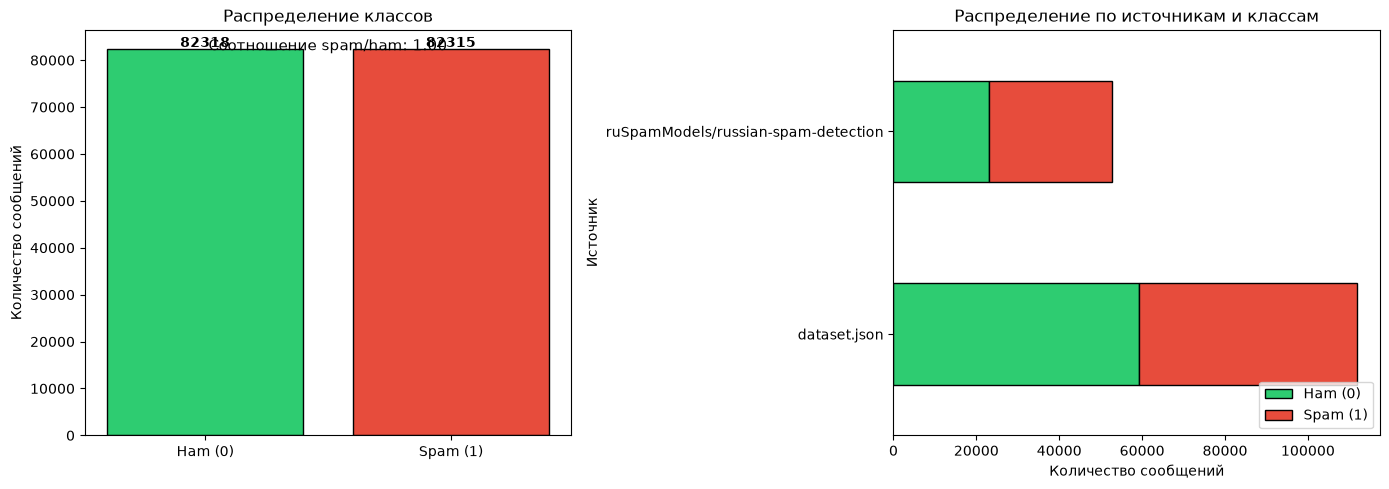


Итого: 164633 строк
  Ham (0): 82318
  Spam (1): 82315
  Соотношение: 1.00


In [21]:
_fig, _axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение классов
_class_counts = df_preprocessed['label'].value_counts().sort_index()
_axes[0].bar(['Ham (0)', 'Spam (1)'], _class_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
for _i, _v in enumerate(_class_counts.values):
    _axes[0].text(_i, _v + 500, str(_v), ha='center', fontweight='bold')
_axes[0].set_title('Распределение классов')
_axes[0].set_ylabel('Количество сообщений')
_ratio = _class_counts.get(1, 0) / max(_class_counts.get(0, 1), 1)
_axes[0].text(0.5, 0.95, f'Соотношение spam/ham: {_ratio:.2f}', transform=_axes[0].transAxes, ha='center', fontsize=11)

# Распределение по источникам и классам
_source_class = df_preprocessed.groupby(['_source', 'label']).size().unstack(fill_value=0)
_source_class.plot(kind='barh', stacked=True, ax=_axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
_axes[1].set_title('Распределение по источникам и классам')
_axes[1].set_xlabel('Количество сообщений')
_axes[1].set_ylabel('Источник')
_axes[1].legend(['Ham (0)', 'Spam (1)'], loc='lower right')

plt.tight_layout()
plt.show()

print(f'\nИтого: {len(df_preprocessed)} строк')
print(f"  Ham (0): {len(df_preprocessed[df_preprocessed['label'] == 0])}")
print(f"  Spam (1): {len(df_preprocessed[df_preprocessed['label'] == 1])}")
print(f"  Соотношение: {_ratio:.2f}")

### Выявление корреляции между новыми параметрами и целевой переменной

Для каждого числового признака выполняется сортировка датафрейма
по убыванию и визуальный анализ распределения классов.
Затем вычисляется полная корреляционная матрица.

Количество эмодзи действительно может влиять на результативность модели.
Спам-сообщения часто содержат больше эмодзи, чем обычные.

In [22]:
df_preprocessed.sort_values('emojis', ascending=False)

,text,label,_source,emojis,newlines,whitespaces,links,tags,length,capital_ratio,...,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity,text_raw,text_normalized,text_preprocessed
107593,🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴\n🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴\n🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴\n⚫️⚫️⚫️⚫...,1,dataset.json,1320,161,0,0,0,2401,1.000000,...,0,0,21,0.000000,0,0,6,🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴\n🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴\n🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴\n⚫️⚫️⚫️⚫...,🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴\n🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴\n🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴\n⚫️⚫️⚫️⚫...,слава україн героям слава слава зсу слава азов...
102756,Рома:\nВаш бобофоне🫘🫘🫘🫘🫛🫛😮😮поселился демон 👺 👺...,1,dataset.json,717,1,0,0,0,3376,0.016343,...,0,0,0,0.000000,0,0,8,Рома:\nВаш бобофоне🫘🫘🫘🫘🫛🫛😮😮поселился демон 👺 👺...,Рома:\nВаш бобофоне🫘🫘🫘🫘🫛🫛😮😮поселился демон 👺 👺...,рома ваш бобофонепоселился демон чтоб этого из...
91913,эй верни мне мою кожу🤣🤣✌️✌️существо из тумана ...,1,dataset.json,561,0,0,0,0,3549,0.002868,...,0,0,0,0.000000,0,0,3,эй верни мне мою кожу🤣🤣✌️✌️существо из тумана ...,эй верни мне мою кожу🤣🤣✌️✌️существо из тумана ...,эй верни мне мою кожусущество из тумана поедае...
98303,❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️\n❤️❤️⬛️❤️❤️❤️❤️❤️...,1,dataset.json,480,77,28,0,0,2412,0.161392,...,0,0,4,0.000000,0,0,14,❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️\n❤️❤️⬛️❤️❤️❤️❤️❤️...,❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️\n❤️❤️⬛️❤️❤️❤️❤️❤️...,we are hiring sales retention do you speak ger...
62011,🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸<br>🌸🌸🌸🌸🌸🍋🍋🌸🌸🌸🍋🍋🌸🌸🌸🌸🌸\n🌸🌸🌸🌸🍋🍋...,1,dataset.json,466,38,19,1,0,1082,0.209677,...,0,0,0,0.024954,1,0,3,🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸<br>🌸🌸🌸🌸🌸🍋🍋🌸🌸🌸🍋🍋🌸🌸🌸🌸🌸\n🌸🌸🌸🌸🍋🍋...,🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸🌸\n🌸🌸🌸🌸🌸🍋🍋🌸🌸🌸🍋🍋🌸🌸🌸🌸🌸\n🌸🌸🌸🌸🍋🍋🍋🍋...,retention manager горячий трафик ру много слад...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54384,"Здравствуйте! Смотрите внимательней, у Вас бал...",0,dataset.json,0,0,0,0,0,53,0.066667,...,0,0,1,0.000000,0,0,0,"Здравствуйте! Смотрите внимательней, у Вас бал...","Здравствуйте! Смотрите внимательней, у Вас бал...",здравствуйте смотрите внимательней у вас балл ...
54381,Ожидайте тогда проверки от модератора,0,dataset.json,0,0,0,0,0,37,0.030303,...,0,0,0,0.000000,0,0,0,Ожидайте тогда проверки от модератора,Ожидайте тогда проверки от модератора,ожидайте тогда проверки от модератора
54380,Отправили повторно заявление на проверку?,0,dataset.json,0,0,0,0,0,41,0.027778,...,0,0,0,0.000000,0,0,0,Отправили повторно заявление на проверку?,Отправили повторно заявление на проверку?,отправили повторно заявление на проверку
54379,Вы ранее не подавали документы и не отправляли...,0,dataset.json,0,0,0,0,0,70,0.016949,...,0,0,0,0.000000,0,0,0,Вы ранее не подавали документы и не отправляли...,Вы ранее не подавали документы и не отправляли...,вы ранее не подавали документы и не отправляли...


Количество символов новой строки не показывает явной закономерности
с целевой переменной.

In [23]:
df_preprocessed.sort_values('newlines', ascending=False)

,text,label,_source,emojis,newlines,whitespaces,links,tags,length,capital_ratio,...,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity,text_raw,text_normalized,text_preprocessed
59586,"ʙᥴᥱⲙ ᤋдρᥲʙᥴᴛʙуᥔᴛᥱ ,<br>ᥙ ϶ᴛ᧐ нᥲδ᧐ρ ʙ᧐ ɸ᧘уд\n""н...",1,dataset.json,81,236,82,0,0,2042,0.115811,...,0,0,2,0.000000,1,0,3,"ʙᥴᥱⲙ ᤋдρᥲʙᥴᴛʙуᥔᴛᥱ ,<br>ᥙ ϶ᴛ᧐ нᥲδ᧐ρ ʙ᧐ ɸ᧘уд\n""н...","ʙᥴᥱⲙ ᤋдρᥲʙᥴᴛʙуᥔᴛᥱ ,\nᥙ ϶ᴛ᧐ нᥲδ᧐ρ ʙ᧐ ɸ᧘уд\n""нᥱɸ...",ʙᥴᥱⲙ ᤋдρᥲʙᥴᴛʙуᥔᴛᥱ ᥙ ᴛ᧐ нᥲδ᧐ρ ʙ᧐ ɸ᧘уд нᥱɸᥙκ᧐ρ᧐ʙ...
71634,🔠🔠🔠🔠🔠 🔠🔠🔠🔠🔠<br>\n\n🥶🥶🥶 \n\n\n⭐𝗡𝗘𝗧𝗙𝗟𝗜𝗫 𝗣...,1,dataset.json,84,228,125,0,3,2829,0.615570,...,0,1,0,0.000000,1,0,17,🔠🔠🔠🔠🔠 🔠🔠🔠🔠🔠<br>\n\n🥶🥶🥶 \n\n\n⭐𝗡𝗘𝗧𝗙𝗟𝗜𝗫 𝗣...,🔠🔠🔠🔠🔠 🔠🔠🔠🔠🔠\n\n\n🥶🥶🥶 \n\n\n⭐NETFLIX PRI...,netflix priv screen 1 month 99ɪɴʀ2ᴜsᴅ 3 month ...
63196,꧁𓊈𒆜 𝔹𝔼𝕊𝕋 𝕊𝔼ℝ𝕍𝕀ℂ𝔼 𒆜𓊉꧂<br>••••••••••••••••••••••...,1,dataset.json,140,226,109,8,16,3374,0.481178,...,0,0,0,0.080616,1,0,13,꧁𓊈𒆜 𝔹𝔼𝕊𝕋 𝕊𝔼ℝ𝕍𝕀ℂ𝔼 𒆜𓊉꧂<br>••••••••••••••••••••••...,꧁𓊈𒆜 BEST SERVICE 𒆜𓊉꧂\n••••••••••••••••••••••••...,𓊈𒆜 best service 𒆜𓊉 lifetime blue tick rs999 36...
66056,🔫🔫🔫 🔫🔫🔫🔫🔫<br>\n\n🥶🥶🥶 \n\n\n⭐𝗡𝗘𝗧𝗙𝗟𝗜𝗫 𝗣𝗥𝗜𝗩 𝗦𝗖...,1,dataset.json,82,223,122,0,3,2368,0.733840,...,0,0,0,0.000000,1,0,17,🔫🔫🔫 🔫🔫🔫🔫🔫<br>\n\n🥶🥶🥶 \n\n\n⭐𝗡𝗘𝗧𝗙𝗟𝗜𝗫 𝗣𝗥𝗜𝗩 𝗦𝗖...,🔫🔫🔫 🔫🔫🔫🔫🔫\n\n\n🥶🥶🥶 \n\n\n⭐NETFLIX PRIV SCRE...,netflix priv screen 1 month 99ɪɴʀ2ᴜsᴅ 3 month ...
62800,🔤🔤🔤🔤🔤🔤<br><br><br>🔠🔠🔠🔠🔠🔠🔠🔠 🔠🔠🔠🔠\n\n\n\nБЕСПЛА...,1,dataset.json,76,222,112,0,2,3132,0.651022,...,0,0,0,0.000000,3,1,8,🔤🔤🔤🔤🔤🔤<br><br><br>🔠🔠🔠🔠🔠🔠🔠🔠 🔠🔠🔠🔠\n\n\n\nБЕСПЛА...,🔤🔤🔤🔤🔤🔤\n\n\n🔠🔠🔠🔠🔠🔠🔠🔠 🔠🔠🔠🔠\n\n\n\nБЕСПЛАТНАЯ Д...,бесплатная доставка по метро почтой по рб дост...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56744,Мы кажется нашли 👀,0,dataset.json,1,0,0,0,0,18,0.071429,...,0,0,0,0.000000,0,0,1,Мы кажется нашли 👀,Мы кажется нашли 👀,мы кажется нашли
56740,Или последний вариант ответа✅ специально для вас,0,dataset.json,1,0,0,0,0,48,0.024390,...,0,0,0,0.000000,0,0,1,Или последний вариант ответа✅ специально для вас,Или последний вариант ответа✅ специально для вас,или последний вариант ответа специально для вас
56738,"Надеемся, что уже совсем скоро и ты вновь полу...",0,dataset.json,1,0,0,0,0,67,0.018519,...,0,0,0,0.000000,0,0,1,"Надеемся, что уже совсем скоро и ты вновь полу...","Надеемся, что уже совсем скоро и ты вновь полу...",надеемся что уже совсем скоро и ты вновь получ...
56734,⚡️ Приходи и ты на экскурсии в СТАНКИН 👉 visit...,0,dataset.json,1,0,0,1,0,57,0.186047,...,0,0,0,0.280702,0,0,1,⚡️ Приходи и ты на экскурсии в СТАНКИН 👉 visit...,⚡️ Приходи и ты на экскурсии в СТАНКИН 👉 visit...,приходи и ты на экскурсии в станкин [LINK]


Количество лишних пробелов может влиять на результативность модели.

In [24]:
df_preprocessed.sort_values('whitespaces', ascending=False)

,text,label,_source,emojis,newlines,whitespaces,links,tags,length,capital_ratio,...,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity,text_raw,text_normalized,text_preprocessed
82891,–°– ━━━━➳༻❀✿❀༺➳━━━━ –°–\n ╭──────╯• ✻ ...,1,dataset.json,0,93,176,0,3,2309,0.084337,...,0,0,0,0.000000,0,1,0,–°– ━━━━➳༻❀✿❀༺➳━━━━ –°–\n ╭──────╯• ✻ ...,–°– ━━━━➳༻❀✿❀༺➳━━━━ –°–\n ╭──────╯• ✻ ...,welcome island of lost souls пиᴀᴩ ᴨᴏᴄᴛ ты чᴇᴧᴏ...
71540,Занимаемcя поставкой теxники Sаmsung из ОАЭ🇦🇪 ...,1,dataset.json,93,182,172,5,0,2464,0.249237,...,0,0,0,0.046672,1,0,18,Занимаемcя поставкой теxники Sаmsung из ОАЭ🇦🇪 ...,Занимаемcя поставкой теxники Sаmsung из ОАЭ🇦🇪 ...,занимаемcя поставкой теxники sаmsung из оаэ да...
68959,🤖 П р о в е р ь д е в у ш е к ...,1,dataset.json,12,21,166,0,4,637,0.140000,...,0,0,0,0.000000,2,0,3,🤖 П р о в е р ь д е в у ш е к ...,🤖 П р о в е р ь д е в у ш е к ...,п р о в е р ь д е в у ш е к н а и н т и м н ы ...
68895,И н т и м к и с п о м о щ ь...,1,dataset.json,12,15,162,0,4,635,0.134831,...,0,0,0,0.000000,1,0,3,И н т и м к и с п о м о щ ь...,И н т и м к и с п о м о щ ь...,и н т и м к и с п о м о щ ь ю и и н о в ы е т ...
80956,АРАБЫ 🇦🇪 \nСАМЫЕ НИЗКИЕ ЦЕНЫ 🙋‍♂️\nОРИГИНАЛ 1...,1,dataset.json,29,70,151,0,1,2190,0.990164,...,0,0,0,0.000000,0,0,5,АРАБЫ 🇦🇪 \nСАМЫЕ НИЗКИЕ ЦЕНЫ 🙋‍♂️\nОРИГИНАЛ 1...,АРАБЫ 🇦🇪 \nСАМЫЕ НИЗКИЕ ЦЕНЫ 🙋♂️\nОРИГИНАЛ 10...,арабы самые низкие цены оригинал 100 в картонн...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8,Здравствуйте. Не смог найти списки поступающих...,0,dataset.json,0,0,0,0,0,85,0.056338,...,0,0,0,0.000000,0,0,0,Здравствуйте. Не смог найти списки поступающих...,Здравствуйте. Не смог найти списки поступающих...,здравствуйте не смог найти списки поступающих ...
7,"Было бы неплохо, если бы прикладывались ссылки...",0,dataset.json,0,0,0,0,0,84,0.014085,...,0,0,0,0.000000,0,0,0,"Было бы неплохо, если бы прикладывались ссылки...","Было бы неплохо, если бы прикладывались ссылки...",было бы неплохо если бы прикладывались ссылки ...
6,Лучшая специальность! Жаль с моими баллами не ...,0,dataset.json,0,0,0,0,0,53,0.045455,...,0,0,1,0.000000,0,0,0,Лучшая специальность! Жаль с моими баллами не ...,Лучшая специальность! Жаль с моими баллами не ...,лучшая специальность жаль с моими баллами не п...
5,"Добрый день! Да, необходимо пройти быструю рег...",0,dataset.json,0,0,0,1,0,91,0.027027,...,0,0,1,0.296703,0,0,0,"Добрый день! Да, необходимо пройти быструю рег...","Добрый день! Да, необходимо пройти быструю рег...",добрый день да необходимо пройти быструю регис...


Количество ссылок может влиять на результативность модели.

In [25]:
df_preprocessed.sort_values('links', ascending=False)

,text,label,_source,emojis,newlines,whitespaces,links,tags,length,capital_ratio,...,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity,text_raw,text_normalized,text_preprocessed
67320,"Completely FREE,crypto earning,NO deposit,NO i...",1,dataset.json,0,101,0,101,0,3864,0.038699,...,17,1,1,0.955487,1,0,0,"Completely FREE,crypto earning,NO deposit,NO i...","Completely FREE,crypto earning,NO deposit,NO i...",completely freecrypto earningno depositno inve...
70823,"Completely FREE,crypto earning,NO deposit,NO i...",1,dataset.json,0,85,0,85,0,3412,0.058450,...,4,1,1,0.954279,1,1,0,"Completely FREE,crypto earning,NO deposit,NO i...","Completely FREE,crypto earning,NO deposit,NO i...",completely freecrypto earningno depositno inve...
67578,https://bnbhs.com/ref/193822319366<br>https://...,1,dataset.json,0,83,0,83,0,3770,0.141146,...,5,0,0,0.976658,1,0,0,https://bnbhs.com/ref/193822319366<br>https://...,https://bnbhs.com/ref/193822319366\nhttps://mi...,[LINK] [LINK] [LINK] [LINK] [LINK] [LINK] [LIN...
78747,🔷ජිල් විතරයි 👾 \nhttps://shorturl....,1,dataset.json,131,104,47,77,1,3653,0.111549,...,0,0,4,0.512456,0,0,41,🔷ජිල් විතරයි 👾 \nhttps://shorturl....,🔷ජිල් විතරයි 👾 \nhttps://shorturl....,ජල වතරය [LINK] වල සපනයනන [LINK] ඇලඩන [LINK] සක...
72410,"🐍KOBRA🐍1010🐍, [30.09.2023 13:12]<br>🐍KOBRA🐍101...",1,dataset.json,16,105,19,69,0,3138,0.247348,...,0,0,0,0.813576,1,0,4,"🐍KOBRA🐍1010🐍, [30.09.2023 13:12]<br>🐍KOBRA🐍101...","🐍KOBRA🐍1010🐍, [30.09.2023 13:12]\n🐍KOBRA🐍1010🐍...",kobra1010 30092023 1312 kobra1010 28072023 171...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164628,Купим usdt работаем больше чем в 100 странах о...,1,ruSpamModels/russian-spam-detection,0,0,0,0,0,154,0.008197,...,0,1,0,0.000000,0,0,0,Купим usdt работаем больше чем в 100 странах о...,Купим usdt работаем больше чем в 100 странах о...,купим usdt работаем больше чем в 100 странах о...
164627,Привет нужни люди на гибкий график возможность...,1,ruSpamModels/russian-spam-detection,0,0,0,0,0,128,0.009615,...,0,0,0,0.000000,0,0,0,Привет нужни люди на гибкий график возможность...,Привет нужни люди на гибкий график возможность...,привет нужни люди на гибкий график возможность...
164610,Hачни зapaбатывaть ужe сeгодня дo 16 000 в дeн...,1,ruSpamModels/russian-spam-detection,0,0,0,0,0,58,0.023256,...,0,0,0,0.000000,0,0,0,Hачни зapaбатывaть ужe сeгодня дo 16 000 в дeн...,Hачни зapaбатывaть ужe сeгодня дo 16 000 в дeн...,hачни зapaбатывaть ужe сeгодня дo 16 000 в дeн...
164609,Дᴏбᴩᴏгᴏ ʙремени суᴛоᴋ πρедлᴀгаю ᴄᴏтρудничеᴄтʙᴏ...,1,ruSpamModels/russian-spam-detection,0,0,0,0,0,170,0.007042,...,0,0,0,0.000000,0,0,0,Дᴏбᴩᴏгᴏ ʙремени суᴛоᴋ πρедлᴀгаю ᴄᴏтρудничеᴄтʙᴏ...,Дᴏбᴩᴏгᴏ ʙремени суᴛоᴋ πρедлᴀгаю ᴄᴏтρудничеᴄтʙᴏ...,дᴏбᴩᴏгᴏ ʙремени суᴛоᴋ πρедлᴀгаю ᴄᴏтρудничеᴄтʙᴏ...


Количество тегов может влиять на результативность модели.

In [26]:
df_preprocessed.sort_values('tags', ascending=False)

,text,label,_source,emojis,newlines,whitespaces,links,tags,length,capital_ratio,...,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity,text_raw,text_normalized,text_preprocessed
94616,Привет @Sergey_VS44 @Overdogs_heteroploidy @L...,1,dataset.json,0,0,1,0,100,1377,0.145349,...,0,0,0,0.000000,0,0,0,Привет @Sergey_VS44 @Overdogs_heteroploidy @L...,Привет @Sergey_VS44 @Overdogs_heteroploidy @L...,привет [TAG] [TAG] [TAG] [TAG] [TAG] [TAG] [TA...
66735,✔️ SORGU PANELİ SATIN ALMAK İÇİN ✔️<br>\n\n\n@...,1,dataset.json,13,97,36,0,91,1340,0.207057,...,0,0,0,0.000000,1,0,3,✔️ SORGU PANELİ SATIN ALMAK İÇİN ✔️<br>\n\n\n@...,✔️ SORGU PANELİ SATIN ALMAK İÇİN ✔️\n\n\n\n@Jo...,sorgu paneli satin almak için [TAG] [TAG] [TAG...
105759,❓ FAQ | ЧТО ЭТО?\n🔽🔽🔽\n@antiantigospartia_FAQ\...,1,dataset.json,106,99,13,0,87,3016,0.072854,...,0,0,0,0.000000,0,0,14,❓ FAQ | ЧТО ЭТО?\n🔽🔽🔽\n@antiantigospartia_FAQ\...,❓ FAQ | ЧТО ЭТО?\n🔽🔽🔽\n@antiantigospartia_FAQ\...,faq что это [TAG] владелец [TAG] по поводу в с...
67965,💠SHARE YOUR LINK💠<br>\n𝟖𝟎 𝐠𝐫𝐨𝐮𝐩𝐬 𝐟𝐨𝐫 𝐥𝐢𝐧𝐤 𝐬𝐡𝐚𝐫...,1,dataset.json,2,91,93,2,81,1994,0.209976,...,0,0,0,0.036108,1,1,1,💠SHARE YOUR LINK💠<br>\n𝟖𝟎 𝐠𝐫𝐨𝐮𝐩𝐬 𝐟𝐨𝐫 𝐥𝐢𝐧𝐤 𝐬𝐡𝐚𝐫...,💠SHARE YOUR LINK💠\n\n80 groups for link share....,share your link 80 groups for link share [LINK...
69609,👑👑SHARE LINK👑👑<br>\n𝟖𝟎 𝐠𝐫𝐨𝐮𝐩𝐬 𝐟𝐨𝐫 𝐥𝐢𝐧𝐤 𝐬𝐡𝐚𝐫𝐞.-...,1,dataset.json,4,88,92,2,80,1924,0.168224,...,0,0,0,0.033264,1,1,1,👑👑SHARE LINK👑👑<br>\n𝟖𝟎 𝐠𝐫𝐨𝐮𝐩𝐬 𝐟𝐨𝐫 𝐥𝐢𝐧𝐤 𝐬𝐡𝐚𝐫𝐞.-...,👑👑SHARE LINK👑👑\n\n80 groups for link share.- \...,share link 80 groups for link share [LINK] 1 [...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53081,"#СТАНКИНактив\n\n⭐️ Привет, Абитуриент!\n\n😇 Н...",0,dataset.json,6,16,8,0,0,813,0.074924,...,0,0,3,0.000000,0,0,6,"#СТАНКИНактив\n\n⭐️ Привет, Абитуриент!\n\n😇 Н...","#СТАНКИНактив\n\n⭐️ Привет, Абитуриент!\n\n😇 Н...",станкинактив привет абитуриент напоминаем тебе...
53082,"​​✔️ Владимир Серебренный, и.о. ректора МГТУ «...",0,dataset.json,2,10,5,0,0,1138,0.055731,...,0,0,2,0.000000,0,0,2,"​​✔️ Владимир Серебренный, и.о. ректора МГТУ «...","✔️ Владимир Серебренный, и.о. ректора МГТУ «СТ...",владимир серебренный ио ректора мгту станкин в...
53083,"#СТАНКИНЧаВо\n\n✌🏻 Привет, абитуриент!\n\n🔧 В...",0,dataset.json,4,10,6,0,0,602,0.083333,...,0,0,1,0.000000,0,0,4,"#СТАНКИНЧаВо\n\n✌🏻 Привет, абитуриент!\n\n🔧 В...","#СТАНКИНЧаВо\n\n✌🏻 Привет, абитуриент!\n\n🔧 В...",станкинчаво привет абитуриент в сегодняшнем вы...
53084,"#СТАНКИНпоздравляет\n\n👋 3, 2, 1... Привет, Аб...",0,dataset.json,5,12,7,0,0,627,0.062880,...,0,0,1,0.000000,0,0,5,"#СТАНКИНпоздравляет\n\n👋 3, 2, 1... Привет, Аб...","#СТАНКИНпоздравляет\n\n👋 3, 2, 1... Привет, Аб...",станкинпоздравляет 3 2 1 привет абитуриент вот...


Для проверки корреляции из датафрейма удаляются текстовые колонки,
остаются только числовые признаки и метка класса.

In [27]:
df_corr = deepcopy(df_preprocessed)
df_corr = df_corr.drop(columns=['text', 'text_raw', 'text_normalized', 'text_preprocessed'], errors='ignore')
df_corr.drop(columns=['_source'], errors='ignore', inplace=True)

In [28]:
df_corr.corr()

,label,emojis,newlines,whitespaces,links,tags,length,capital_ratio,punctuation_count,digit_count,...,word_count,unique_word_ratio,repeat_char_ratio,phone_count,has_crypto,exclamation_count,url_ratio,html_tag_count,has_markdown,emoji_diversity
label,1.000000,0.207830,0.187293,0.150838,0.070365,0.141172,0.032748,0.200196,0.176769,0.136732,...,0.048632,-0.075733,0.211199,0.029412,0.165203,0.097687,0.071854,0.254513,0.082460,0.235137
emojis,0.207830,1.000000,0.688868,0.577173,0.307081,0.246302,0.439894,0.298600,0.678762,0.380996,...,0.413755,-0.389355,0.235599,0.107081,0.208876,0.178937,0.121327,0.288195,0.085867,0.756429
newlines,0.187293,0.688868,1.000000,0.830329,0.442489,0.337986,0.705647,0.293395,0.723932,0.568656,...,0.687976,-0.538423,0.126236,0.176199,0.265674,0.266676,0.148279,0.346733,0.209989,0.722882
whitespaces,0.150838,0.577173,0.830329,1.000000,0.356390,0.278967,0.587038,0.243523,0.597614,0.457412,...,0.568268,-0.465697,0.191835,0.126254,0.216266,0.216711,0.126662,0.332481,0.185725,0.608248
links,0.070365,0.307081,0.442489,0.356390,1.000000,0.086823,0.295350,0.100930,0.406023,0.447972,...,0.200332,-0.232424,0.042624,0.247337,0.182911,0.038092,0.454318,0.176302,0.032154,0.303861
tags,0.141172,0.246302,0.337986,0.278967,0.086823,1.000000,0.251413,0.149106,0.280576,0.202132,...,0.244731,-0.230783,0.063531,0.063591,0.102010,0.120943,0.012640,0.145775,0.096842,0.276744
length,0.032748,0.439894,0.705647,0.587038,0.295350,0.251413,1.000000,0.106410,0.613209,0.486375,...,0.971624,-0.635293,0.021191,0.164370,0.189193,0.286712,0.059414,0.186226,0.202026,0.503281
capital_ratio,0.200196,0.298600,0.293395,0.243523,0.100930,0.149106,0.106410,1.000000,0.246333,0.153870,...,0.099205,-0.173163,0.158483,0.044820,0.101020,0.113803,0.104013,0.213891,0.049971,0.312114
punctuation_count,0.176769,0.678762,0.723932,0.597614,0.406023,0.280576,0.613209,0.246333,1.000000,0.463927,...,0.549091,-0.446762,0.159461,0.133566,0.218080,0.244445,0.156568,0.267653,0.162690,0.608053
digit_count,0.136732,0.380996,0.568656,0.457412,0.447972,0.202132,0.486375,0.153870,0.463927,1.000000,...,0.478288,-0.401697,0.113316,0.409885,0.200131,0.102605,0.163106,0.194680,0.105143,0.382468


Итоги корреляции:
- **Эмодзи**, **лишние пробелы**, **переносы строк** оказывают **умеренное влияние** на предсказание класса (`label`).
- **Ссылки** и **тэги** имеют **слабую корреляцию с целевой переменной**, но их использование может быть полезно в сочетании с другими признаками.
- Новые признаки (`html_tag_count`, `has_markdown`, `emoji_diversity`) могут дополнительно улучшить классификацию.

## Сохранение данных

Итоговый датасет сохраняется в `data/processed/preprocessed.csv`.
Колонка `_source` сохраняется для per-source анализа в последующих ноутбуках.
Этот файл используется во всех последующих ноутбуках для обучения моделей.

In [29]:
df_preprocessed.to_csv(PROCESSED_DIR / 'preprocessed.csv', index=False)
print(f'Сохранено: {len(df_preprocessed)} строк, {df_preprocessed.shape[1]} колонок')
print(f'Колонки: {list(df_preprocessed.columns)}')

Сохранено: 164633 строк, 26 колонок
Колонки: ['text', 'label', '_source', 'emojis', 'newlines', 'whitespaces', 'links', 'tags', 'length', 'capital_ratio', 'punctuation_count', 'digit_count', 'avg_word_length', 'word_count', 'unique_word_ratio', 'repeat_char_ratio', 'phone_count', 'has_crypto', 'exclamation_count', 'url_ratio', 'html_tag_count', 'has_markdown', 'emoji_diversity', 'text_raw', 'text_normalized', 'text_preprocessed']
